## 1. Instalasi Library

Library yang digunakan:
- `pymupdf (fitz)`: untuk membaca dan mengekstrak teks dari file PDF
- `pdfplumber`: alternatif parsing PDF, khususnya untuk tabel
- `python-docx`: untuk membaca file DOCX
- `google-generativeai`: untuk mengakses Gemini API sebagai vision model
- `chromadb`: sebagai vector database penyimpan embedding
- `sentence-transformers`: untuk menghasilkan embedding dari teks

In [ ]:
!pip install pymupdf pdfplumber python-docx
!pip install google-generativeai
!pip install chromadb sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 76.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.

## 2. Mount Google Drive

Dataset berupa file PDF dan DOCX disimpan di Google Drive.
Drive di-mount agar Colab bisa mengakses file secara langsung
tanpa perlu upload ulang setiap sesi baru.

Mount Drive

Ini ntar diganti dataset_path nya sesuai yang kelen upload

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/database-modul5-ai'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Eksplorasi Dataset

Sebelum memproses dokumen, dilakukan pengecekan isi folder dataset
untuk mengetahui jenis dan jumlah file yang tersedia.
Dataset terdiri dari 7 file PDF dan 1 file DOCX yang mencakup
dokumen akademik ITS seperti kurikulum, peraturan, magang, dan kalender akademik.

In [ ]:
import os

# lihat semua file dulu
for f in os.listdir(dataset_path):
    print(f)

Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf
Visi Misi Departemen.pdf
Peraturan Akademik.pdf
Nilai snbt 2025.pdf
Kurikulum.pdf
Sosialisasi Magang dan Prestasi DTI.pdf
Jadwal Perkuliahan.docx
Data Dosen.pdf


In [ ]:
import os
import fitz  # pymupdf untuk PDF
from docx import Document  # untuk DOCX

pdf_files = [f for f in os.listdir(dataset_path) if f.endswith('.pdf')]
docx_files = [f for f in os.listdir(dataset_path) if f.endswith('.docx')]

print(f"Total PDF: {len(pdf_files)}")
print(f"Total DOCX: {len(docx_files)}")

Total PDF: 7
Total DOCX: 1


## 4. Ekstraksi Teks Dokumen

Setiap dokumen diekstrak teksnya menggunakan pendekatan berbeda:
- **PDF**: menggunakan PyMuPDF (fitz) dengan ekstraksi per halaman,
  sehingga metadata halaman tetap tersimpan
- **DOCX**: menggunakan python-docx untuk membaca paragraf

Setiap halaman disimpan sebagai dictionary berisi:
- `text`: isi teks halaman
- `page`: nomor halaman
- `source`: nama file sumber

In [ ]:
def extract_pdf(filepath):
    doc = fitz.open(filepath)
    pages = []
    for i, page in enumerate(doc):
        text = page.get_text()
        pages.append({
            "text": text,
            "page": i + 1,
            "source": os.path.basename(filepath)
        })
    return pages

def extract_docx(filepath):
    doc = Document(filepath)
    text = "\n".join([p.text for p in doc.paragraphs])
    return [{
        "text": text,
        "page": 1,
        "source": os.path.basename(filepath)
    }]

In [ ]:
# extract semua file
all_documents = []

for f in pdf_files:
    filepath = os.path.join(dataset_path, f)
    pages = extract_pdf(filepath)
    all_documents.extend(pages)

for f in docx_files:
    filepath = os.path.join(dataset_path, f)
    pages = extract_docx(filepath)
    all_documents.extend(pages)

print(f"Total halaman/dokumen ter-extract: {len(all_documents)}")

Total halaman/dokumen ter-extract: 1039


Cek isi masing" file

In [ ]:
# lihat hasil extract pertama
print(all_documents[0]['source'])
print(all_documents[0]['page'])
print(all_documents[0]['text'][:500])  # 500 karakter pertama

Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf
1
KI~,?l~~NTFRIAN PENI)IDIKAN Tiii`GC~I, SHINS, 
:. ~ 1)Ai~` TIJKNOLOGI 
INSTITUT TEKNOLOGI SEPULUH NOPEMBER 
Kamptls ITS Sukolilo -Surabaya 60111 
"I~elepon : 03 I -X99425 I -54, 5947274, 5945472 (h-hinting} 
I~ax: 03 I -5947264, X950806 
http://~~-ww.its.ac.id 
KEPUTUSAN REKTOR INSTITUT TEKNOLOGI SEPULUH NOPEMBER 
NOMOR 22/IT2/T/HK.00.01/X/2025 
TENTANG 
PERUBAHAN KEDUA ATAS KEPUTUSAN REKTOR INSTITUT TEKNOLOGI SEPULUH 
NOPEMBER NOMOR 3/IT2/T/HK.00.01/I/2025 TENTANG KALENDER AKADEMIK 
INSTITUT TE


## 5. Pembersihan Teks (Text Cleaning)

Hasil ekstraksi PDF mentah sering mengandung noise seperti:
- Karakter encoding rusak (OCR error)
- Whitespace berlebih
- URL dan navigasi menu (khusus dokumen yang bersumber dari website)

Dilakukan dua tahap cleaning:
1. `clean_text()`: menghapus karakter aneh dan whitespace berlebih untuk semua dokumen
2. `clean_web_noise()`: menghapus URL dan sisa navigasi khusus untuk
   Visi Misi Departemen.pdf dan Data Dosen.pdf yang bersumber dari website ITS

In [ ]:
import re

def clean_text(text):
    # hapus karakter aneh/encoding rusak
    text = re.sub(r'[~`\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]', '', text)
    # hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text)
    # trim
    text = text.strip()
    return text

# apply ke semua dokumen
for doc in all_documents:
    doc['text'] = clean_text(doc['text'])

# cek hasilnya
print(all_documents[0]['text'][:500])

KI,?lNTFRIAN PENI)IDIKAN TiiiGCI, SHINS, :. 1)Ai TIJKNOLOGI INSTITUT TEKNOLOGI SEPULUH NOPEMBER Kamptls ITS Sukolilo -Surabaya 60111 "Ielepon : 03 I -X99425 I -54, 5947274, 5945472 (h-hinting} Iax: 03 I -5947264, X950806 http://-ww.its.ac.id KEPUTUSAN REKTOR INSTITUT TEKNOLOGI SEPULUH NOPEMBER NOMOR 22/IT2/T/HK.00.01/X/2025 TENTANG PERUBAHAN KEDUA ATAS KEPUTUSAN REKTOR INSTITUT TEKNOLOGI SEPULUH NOPEMBER NOMOR 3/IT2/T/HK.00.01/I/2025 TENTANG KALENDER AKADEMIK INSTITUT TEKNOLOGI SEPULUH NOPEMBER 


In [ ]:
# cek dokumen lain
for doc in all_documents:
    if doc['source'] != 'Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf':
        print(f"\n=== {doc['source']} - hal {doc['page']} ===")
        print(doc['text'][:300])
        break


=== Visi Misi Departemen.pdf - hal 1 ===
Butuh Bantuan? Silahkan hubungi kami disini: Bantuan () TENTANG KAMI (HTTPS://WWW.ITS.AC.ID/IT/ID/TENTANG-KAMI/) Sambutan Kepala Departemen (https://www.its.ac.id/it/id/tentang-kami/sambutan-kepala-departemen/) Sejarah (https://www.its.ac.id/it/id/tentang-kami/sejarah/) Departemen dalam Angka (https


cek noise semua dokumen

In [ ]:
for source in set([doc['source'] for doc in all_documents]):
    sample = next(doc for doc in all_documents if doc['source'] == source)
    print(f"\n=== {source} ===")
    print(sample['text'][:200])
    print("---")


=== Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf ===
KI,?lNTFRIAN PENI)IDIKAN TiiiGCI, SHINS, :. 1)Ai TIJKNOLOGI INSTITUT TEKNOLOGI SEPULUH NOPEMBER Kamptls ITS Sukolilo -Surabaya 60111 "Ielepon : 03 I -X99425 I -54, 5947274, 5945472 (h-hinting} Iax: 03
---

=== Nilai snbt 2025.pdf ===
TEKNOLOGI INFORMASI 2025 Rekap Skor UTBK 2025 Program Studi Teknologi Informasi ITS Visualisasi Data Subtes Avg Max Min NILAI RATA-RATA 712.39 RATA-RATA TERTINGGI 761.28 Detail Skor Teknologi Informas
---

=== Sosialisasi Magang dan Prestasi DTI.pdf ===
Magang dan Prestasi Departemen Teknologi Informasi Institut Teknologi Sepuluh Nopember Tim Pengelola Magang Departemen Mei 2025 Sosialisasi
---

=== Peraturan Akademik.pdf ===
SALINAN PERATURAN REKTOR INSTITUT TEKNOLOGI SEPULUH NOPEMBER NOMOR 33 TAHUN 2025 TENTANG PERATURAN AKADEMIK INSTITUT TEKNOLOGI SEPULUH NOPEMBER DENGAN RAHMAT TUHAN YANG MAHA ESA REKTOR INSTITUT TEKNOL
---

=== Kurikulum.pdf ===
DOKUMEN KURIKULUM 2023-2028 PRODI : S1 Teknologi I

## 6. Pemrosesan Multimodal dengan Gemini Vision

Dua dokumen tidak dapat diekstrak teksnya secara langsung:
- **Jadwal Perkuliahan.docx**: isinya berupa gambar screenshot tabel jadwal
- **Kalender Akademik.pdf**: hasil scan dokumen fisik sehingga OCR rusak

Solusi: halaman/gambar dirender lalu dikirim ke Gemini Vision (gemini-2.5-flash)
untuk diekstrak isinya secara akurat. Pendekatan ini merupakan bagian dari
Multimodal RAG karena melibatkan pemrosesan gambar sebagai input.

In [ ]:
from PIL import Image
import fitz  # untuk render PDF jadi gambar
# This cell was removed for redundancy.

ekstrak gambar dari docs tabel jadwal

In [ ]:
from docx import Document
from PIL import Image
import io

def extract_images_from_docx(filepath):
    doc = Document(filepath)
    images = []
    for rel in doc.part.rels.values():
        if "image" in rel.target_ref:
            img_data = rel.target_part.blob
            img = Image.open(io.BytesIO(img_data))
            images.append(img)
    return images

# test extract gambar dari jadwal perkuliahan
jadwal_path = os.path.join(dataset_path, 'Jadwal Perkuliahan.docx')
images = extract_images_from_docx(jadwal_path)
print(f"Total gambar ditemukan: {len(images)}")

# tampilkan gambar pertama
images[0].show()

Total gambar ditemukan: 2


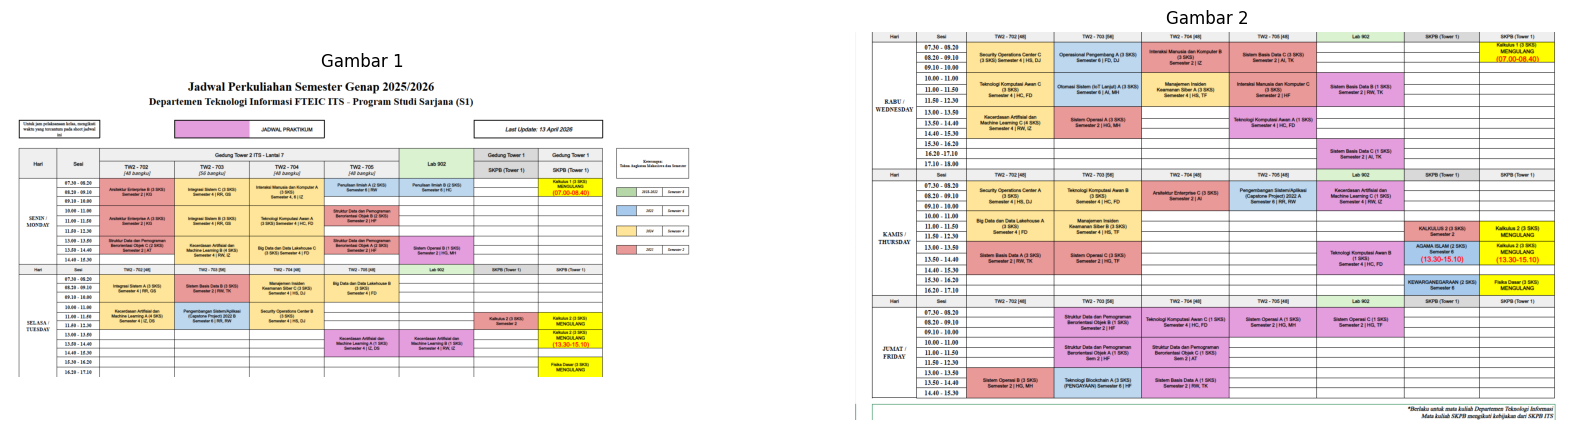

In [ ]:
# tampilkan kedua gambar di notebook
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for i, img in enumerate(images):
    axes[i].imshow(img)
    axes[i].set_title(f'Gambar {i+1}')
    axes[i].axis('off')
plt.show()

Ekstrak gambar

In [ ]:
from PIL import Image
import google.generativeai as genai

GEMINI_API_KEY = "xxx" # Replace with your actual API key
genai.configure(api_key=GEMINI_API_KEY)

# Initialize the model for vision tasks
model = genai.GenerativeModel('gemini-2.5-flash')

def extract_table_with_gemini(image, source_name):
    response = model.generate_content([
        """Ini adalah jadwal perkuliahan dalam bentuk tabel.
        Ekstrak semua informasi secara lengkap dan akurat meliputi:
        - Hari
        - Jam
        - Mata kuliah
        - Kelas/Ruangan
        - Dosen
        Sajikan dalam format yang terstruktur dan mudah dibaca.""",
        image
    ])
    return {
        "text": response.text,
        "page": 1,
        "source": source_name
    }

# extract kedua gambar
jadwal_docs = []
for i, img in enumerate(images):
    print(f"Extracting gambar {i+1}...")
    result = extract_table_with_gemini(img, f'Jadwal Perkuliahan.docx (gambar {i+1})')
    jadwal_docs.append(result)
    print(result['text'][:300])
    print("---------------------------------------------------")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Extracting gambar 1...
Baik, berikut adalah ekstraksi informasi dari jadwal perkuliahan yang Anda berikan, disajikan dalam format yang terstruktur:

**Jadwal Perkuliahan Semester Genap 2025/2026**
Departemen Teknologi Informasi FTEIC ITS - Program Studi Sarjana (S1)

---

### **SENIN / MONDAY**

*   **Jam**: 07.30 - 09.10
---------------------------------------------------
Extracting gambar 2...
Baik, saya akan mengekstrak semua informasi dari jadwal perkuliahan tersebut dan menyajikannya dalam format yang terstruktur dan mudah dibaca.

---

**Jadwal Perkuliahan**

**RABU / WEDNESDAY**

*   **Jam: 07.30 - 10.00**
    *   **Mata Kuliah:** Security Operations Center C (3 SKS)
    *   **Kelas/
---------------------------------------------------


In [ ]:
# tambahkan hasil jadwal ke all_documents
all_documents.extend(jadwal_docs)
print(f"Total dokumen sekarang: {len(all_documents)}")

Total dokumen sekarang: 1041


Render pdf jadi gambar untuk kalender akademik

In [ ]:
def extract_pdf_as_images(filepath):
    doc = fitz.open(filepath)
    images = []
    for i, page in enumerate(doc):
        # render halaman jadi gambar
        pix = page.get_pixmap(dpi=200)
        img_data = pix.tobytes("png")
        img = Image.open(io.BytesIO(img_data))
        images.append({
            "image": img,
            "page": i + 1
        })
    return images

# render kalender akademik
kalender_path = os.path.join(dataset_path, 'Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf')
kalender_images = extract_pdf_as_images(kalender_path)
print(f"Total halaman: {len(kalender_images)}")

Total halaman: 7


run gemini vision untuk extract gambar

In [ ]:
kalender_docs = []
print("Extracting kalender akademik images...")
for item in kalender_images:
    img = item['image']
    page = item['page']
    result = extract_table_with_gemini(img, f'Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf (halaman {page})')
    kalender_docs.append(result)
    print(f"--- Halaman {page} ---")
    print(result['text'][:300])
    print("--------------------")
print(f"Total dokumen kalender diekstrak: {len(kalender_docs)}")

Extracting kalender akademik images...
--- Halaman 1 ---
Maaf, setelah meninjau gambar yang Anda berikan, ini **bukanlah jadwal perkuliahan dalam bentuk tabel**.

Gambar yang Anda berikan adalah sebuah **Surat Keputusan Rektor Institut Teknologi Sepuluh Nopember (ITS)** tentang **Perubahan Kedua atas Keputusan Rektor tentang Kalender Akademik Tahun Akadem
--------------------


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 15101.18ms


--- Halaman 2 ---
Berdasarkan tabel yang diberikan, ini adalah jadwal aktivitas akademik dan perubahannya. Penting untuk dicatat bahwa tabel ini merupakan jadwal *administrasi akademik* dan bukan jadwal perkuliahan spesifik yang mencakup mata kuliah, kelas/ruangan, dan dosen. Oleh karena itu, kolom "Mata kuliah" akan
--------------------
--- Halaman 3 ---
Berdasarkan dokumen yang diberikan, ini adalah **Kalender Akademik** Institut Teknologi Sepuluh Nopember Tahun Akademik 2025/2026, bukan jadwal perkuliahan mata kuliah spesifik.

Oleh karena itu, informasi mengenai:
*   **Mata kuliah**
*   **Kelas/Ruangan**
*   **Dosen**
*   **Jam spesifik untuk per
--------------------
--- Halaman 4 ---
Berdasarkan gambar jadwal yang Anda berikan, saya menemukan bahwa dokumen tersebut adalah **kalender akademik dan jadwal kegiatan pendaftaran/administrasi**, bukan jadwal perkuliahan rinci yang mencantumkan mata kuliah spesifik, hari, jam, kelas/ruangan, dan dosen.

Informasi yang diminta (Hari, Jam
-

In [ ]:
# tambahkan kalender hasil gemini vision ke all_documents
all_documents.extend(kalender_docs)
print(f"Total dokumen sekarang: {len(all_documents)}")

Total dokumen sekarang: 1048


In [ ]:
# hapus kalender lama yang OCR rusak
all_documents = [doc for doc in all_documents
                 if doc['source'] != 'Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf']
print(f"Total dokumen setelah hapus kalender lama: {len(all_documents)}")

Total dokumen setelah hapus kalender lama: 1041


In [ ]:
# rekap per sumber
from collections import Counter

sources = [doc['source'] for doc in all_documents]
counter = Counter(sources)

for source, count in counter.items():
    print(f"{source}: {count} halaman/chunk")

Visi Misi Departemen.pdf: 3 halaman/chunk
Peraturan Akademik.pdf: 56 halaman/chunk
Nilai snbt 2025.pdf: 2 halaman/chunk
Kurikulum.pdf: 897 halaman/chunk
Sosialisasi Magang dan Prestasi DTI.pdf: 62 halaman/chunk
Data Dosen.pdf: 11 halaman/chunk
Jadwal Perkuliahan.docx: 1 halaman/chunk
Jadwal Perkuliahan.docx (gambar 1): 1 halaman/chunk
Jadwal Perkuliahan.docx (gambar 2): 1 halaman/chunk
Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf (halaman 1): 1 halaman/chunk
Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf (halaman 2): 1 halaman/chunk
Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf (halaman 3): 1 halaman/chunk
Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf (halaman 4): 1 halaman/chunk
Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf (halaman 5): 1 halaman/chunk
Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf (halaman 6): 1 halaman/chunk
Kalender-Akademik-ITS-Thn-Akademik-2025-2026.pdf (halaman 7): 1 halaman/chunk


Cleaning noise visi misi data dosen

In [ ]:
def clean_web_noise(text):
    # hapus URL (termasuk kapital)
    text = re.sub(r'https?://\S+', '', text, flags=re.IGNORECASE)
    # hapus kurung kosong atau kurung gantung
    text = re.sub(r'\(\s*\)', '', text)
    text = re.sub(r'\($', '', text)
    text = re.sub(r'\s+\(', ' ', text)
    # hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# apply ulang
for doc in all_documents:
    if doc['source'] in web_sources:
        doc['text'] = clean_web_noise(doc['text'])

# cek lagi
sample = next(doc for doc in all_documents if doc['source'] == 'Visi Misi Departemen.pdf')
print(sample['text'][:300])

NameError: name 'web_sources' is not defined

## 7. Chunking Dokumen

Dokumen panjang dipotong menjadi chunk-chunk kecil agar:
- Retrieval lebih presisi dan tidak mengambil konteks terlalu besar
- Embedding lebih representatif per topik

Konfigurasi chunking:
- `chunk_size = 500` karakter: cukup untuk satu paragraf/topik
- `chunk_overlap = 50` karakter: overlap untuk menjaga konteks antar chunk
- Dokumen pendek (< 500 karakter) langsung dijadikan 1 chunk

Total chunks yang dihasilkan: 3578 chunks dari seluruh dokumen.

In [ ]:
def chunk_documents(documents, chunk_size=500, chunk_overlap=50):
    chunks = []
    for doc in documents:
        text = doc['text']
        if len(text) < chunk_size:
            # kalau teks pendek, langsung jadikan 1 chunk
            chunks.append({
                "text": text,
                "source": doc['source'],
                "page": doc['page'],
                "chunk_id": len(chunks)
            })
        else:
            # potong jadi beberapa chunk dengan overlap
            start = 0
            while start < len(text):
                end = start + chunk_size
                chunk_text = text[start:end]
                chunks.append({
                    "text": chunk_text,
                    "source": doc['source'],
                    "page": doc['page'],
                    "chunk_id": len(chunks)
                })
                start += chunk_size - chunk_overlap

    return chunks

all_chunks = chunk_documents(all_documents)
print(f"Total chunks: {len(all_chunks)}")
print(f"\nContoh chunk pertama:")
print(all_chunks[0])

Total chunks: 3588

Contoh chunk pertama:
{'text': 'Butuh Bantuan? Silahkan hubungi kami disini: Bantuan () TENTANG KAMI (HTTPS://WWW.ITS.AC.ID/IT/ID/TENTANG-KAMI/) Sambutan Kepala Departemen (https://www.its.ac.id/it/id/tentang-kami/sambutan-kepala-departemen/) Sejarah (https://www.its.ac.id/it/id/tentang-kami/sejarah/) Departemen dalam Angka (https://www.its.ac.id/it/id/tentang-kami/departemen-dalam-angka-2/) Visi dan Misi (https://www.its.ac.id/it/id/tentang-kami/visi-dan-misi/) Visi Departemen Menjadi pengelola program studi bidang teknologi ', 'source': 'Visi Misi Departemen.pdf', 'page': 1, 'chunk_id': 0}


## 8. Embedding dan Penyimpanan ke Vector Database

Setiap chunk diubah menjadi vektor numerik (embedding) menggunakan
model `paraphrase-multilingual-MiniLM-L12-v2` dari SentenceTransformers.

Alasan pemilihan model ini:
- Mendukung bahasa Indonesia
- Ukuran ringan sehingga cepat diproses di Colab
- Performa semantic similarity yang baik untuk teks pendek-menengah

Embedding disimpan ke **ChromaDB** sebagai vector database lokal.
Setiap chunk disimpan beserta metadata source dan nomor halaman
untuk mendukung explainability dan source tracking.

In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer

# load embedding model
print("Loading embedding model...")
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Model loaded!")

# setup chromadb
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name="banaspati_docs")
print("ChromaDB collection created!")

Loading embedding model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!
ChromaDB collection created!


input chunk ke chromadb

In [ ]:
# embed dan simpan semua chunks ke chromadb
print("Memasukkan chunks ke ChromaDB...")

batch_size = 100
for i in range(0, len(all_chunks), batch_size):
    batch = all_chunks[i:i+batch_size]

    texts = [c['text'] for c in batch]
    ids = [str(c['chunk_id']) for c in batch]
    metadatas = [{"source": c['source'], "page": c['page']} for c in batch]

    # embed teks
    embeddings = embedding_model.encode(texts).tolist()

    # simpan ke chromadb
    collection.add(
        documents=texts,
        embeddings=embeddings,
        metadatas=metadatas,
        ids=ids
    )

    print(f"Progress: {min(i+batch_size, len(all_chunks))}/{len(all_chunks)} chunks")

print(f"\nSelesai! Total chunks di ChromaDB: {collection.count()}")

Memasukkan chunks ke ChromaDB...
Progress: 100/3588 chunks
Progress: 200/3588 chunks
Progress: 300/3588 chunks
Progress: 400/3588 chunks
Progress: 500/3588 chunks
Progress: 600/3588 chunks
Progress: 700/3588 chunks
Progress: 800/3588 chunks
Progress: 900/3588 chunks
Progress: 1000/3588 chunks
Progress: 1100/3588 chunks
Progress: 1200/3588 chunks
Progress: 1300/3588 chunks
Progress: 1400/3588 chunks
Progress: 1500/3588 chunks
Progress: 1600/3588 chunks
Progress: 1700/3588 chunks
Progress: 1800/3588 chunks
Progress: 1900/3588 chunks
Progress: 2000/3588 chunks
Progress: 2100/3588 chunks
Progress: 2200/3588 chunks
Progress: 2300/3588 chunks
Progress: 2400/3588 chunks
Progress: 2500/3588 chunks
Progress: 2600/3588 chunks
Progress: 2700/3588 chunks
Progress: 2800/3588 chunks
Progress: 2900/3588 chunks
Progress: 3000/3588 chunks
Progress: 3100/3588 chunks
Progress: 3200/3588 chunks
Progress: 3300/3588 chunks
Progress: 3400/3588 chunks
Progress: 3500/3588 chunks
Progress: 3588/3588 chunks

Sel

## 9. Implementasi Fungsi Retrieval

Fungsi `retrieve(query, top_k)` menerima pertanyaan user dan mengembalikan
dokumen paling relevan dari ChromaDB berdasarkan kemiripan semantik.

Alur retrieval:
1. Query di-embed menggunakan model yang sama dengan indexing
2. ChromaDB mencari chunk dengan jarak vektor terkecil (cosine distance)
3. Hasil dikembalikan beserta metadata source, halaman, dan score

Semakin kecil score = semakin relevan (ChromaDB menggunakan distance, bukan similarity).

In [ ]:
def retrieve(query, top_k=5):
    # embed query
    query_embedding = embedding_model.encode([query]).tolist()

    # cari di chromadb
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=top_k
    )

    # format hasil
    retrieved = []
    for i in range(len(results['documents'][0])):
        retrieved.append({
            "text": results['documents'][0][i],
            "source": results['metadatas'][0][i]['source'],
            "page": results['metadatas'][0][i]['page'],
            "score": results['distances'][0][i]
        })

    return retrieved

# test retrieve
# test beberapa query
queries = [
    "berapa durasi minimal magang DUDI?",
    "apa itu CPL di kurikulum TI ITS?",
    "jadwal kuliah hari senin"
]

for q in queries:
    print(f"Query: {q}")
    hasil = retrieve(q, top_k=3)
    for doc in hasil:
        print(f"  → {doc['source']} hal {doc['page']} (score: {doc['score']:.4f})")
        print(f"     {doc['text'][:100]}")
    print()

Query: berapa durasi minimal magang DUDI?
  → Sosialisasi Magang dan Prestasi DTI.pdf hal 7 (score: 7.2844)
     Panduan Umum Magang DUDI Institut Teknologi Sepuluh Nopember ● Pelaksanaan Program Magang DUDI ini m
  → Sosialisasi Magang dan Prestasi DTI.pdf hal 29 (score: 8.7397)
     Sistem Konversi SKS Institut Teknologi Sepuluh Nopember ● Konversi Tabung Sistem konversi dapat dila
  → Peraturan Akademik.pdf hal 34 (score: 9.2884)
     iukur dalam bentuk SKEM pada setiap semester dan divalidasi oleh dosen wall. Pasal 50 i r (1) Mahasi

Query: apa itu CPL di kurikulum TI ITS?
  → Kurikulum.pdf hal 701 (score: 5.0958)
     h melalui proses pembelajaran. 2. CPL yang dibebankan pada mata kuliah adalah beberapa capaian pembe
  → Kurikulum.pdf hal 804 (score: 5.1293)
      diperoleh melalui proses pembelajaran. 2. CPL yang dibebankan pada mata kuliah adalah beberapa capa
  → Kurikulum.pdf hal 896 (score: 5.1552)
      dan ketrampilan sesuai dengan jenjang prodinya yang diperoleh melalui pr

Simpan chunks & collection ke Google Drive biar ga hilang kalau session mati:


In [ ]:
import pickle

# simpan all_chunks
with open('/content/drive/MyDrive/all_chunks.pkl', 'wb') as f:
    pickle.dump(all_chunks, f)

print("Chunks tersimpan!")

Chunks tersimpan!


Tes akhir

In [ ]:
# test dengan berbagai jenis pertanyaan
test_queries = [
    "Apa visi dan misi departemen TI ITS?",
    "Berapa SKS minimal untuk lulus?",
    "Apa syarat mengikuti magang DUDI?",
    "Siapa saja dosen di departemen TI?",
    "Kapan jadwal UAS semester genap 2025?"
]

print("=== TESTING RETRIEVAL ===\n")
for q in test_queries:
    print(f"Query: {q}")
    hasil = retrieve(q, top_k=3)
    for i, doc in enumerate(hasil):
        print(f"  {i+1}. {doc['source']} hal {doc['page']} (score: {doc['score']:.4f})")
        print(f"     {doc['text'][:150]}")
    print()

=== TESTING RETRIEVAL ===

Query: Apa visi dan misi departemen TI ITS?
  1. Visi Misi Departemen.pdf hal 1 (score: 8.5317)
      Menjadi pengelola program studi bidang teknologi informasi yang memiliki reputasi internasional serta berkontribusi pada keilmuan dan kemanusiaan. VI
  2. Kurikulum.pdf hal 15 (score: 9.5424)
     ngkat nasional ataupun internasional. 4. Meningkatkan kerja sama yang produktif dan berkesinambungan antara fakultas mitra nasional dan internasional 
  3. Visi Misi Departemen.pdf hal 3 (score: 9.5797)
     pyright © 2026 Departemen Teknologi Informasi - Institut Teknologi Sepuluh Nopember 15/04/26, 15.36 Visi dan Misi - Departemen Teknologi Informasi htt

Query: Berapa SKS minimal untuk lulus?
  1. Kurikulum.pdf hal 119 (score: 7.3830)
     s FRS berlangsung. Prosedur konversi SKS : 1. Mahasiswa melakukan presentasi kepada dosen wali terkait hasil kegiatan MB-KM. 2. Mahasiswa mengumpulkan
  2. Kurikulum.pdf hal 119 (score: 7.5916)
     SKS 5 Penelitian/Riset Minim

## Analisis Hasil Retrieval
- Query magang & CPL: hasil relevan ✅
- Query dosen: Data Dosen.pdf tidak muncul,
  kemungkinan karena konten terlalu mirip dengan dokumen lain ⚠️
- Query jadwal UAS: score tinggi (>12) menandakan
  relevansi rendah, perlu perbaikan chunking kalender ⚠️